# Chapter 2. 지도 학습

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy as sp
import IPython
import sklearn
import mglearn

print('Python 버전:', sys.version)
print('numpy 버전:', np.__version__)
print('pandas 버전:', pd.__version__)
print('matplotlib 버전:', matplotlib.__version__)
print('SciFy 버전:', sp.__version__)
print('IPython 버전:', IPython.__version__)
print('scikit-learn 버전:', sklearn.__version__)

Python 버전: 3.9.12 (main, Apr  5 2022, 06:56:58) 
[GCC 7.5.0]
numpy 버전: 1.21.5
pandas 버전: 1.4.2
matplotlib 버전: 3.5.1
SciFy 버전: 1.7.3
IPython 버전: 8.2.0
scikit-learn 버전: 1.0.2


## 2.1 분류와 회귀
- 지도 학습에는 분류(classification)와 회귀(regression)
- 분류는 두 개의 클래스로 분류하는 **이진 분류(binary)와** 셋 이상의 클래스로 분류하는 **다중 분류(multiclass)**
- 이진 분류에서 학습하고자 하는 대상을 **양성(positive) 클래스**, 다른 하나를 음성(negative) 클래스
- 회귀는 **연속적인 숫자, 부동소수점(수학 용어로는 실수)를** 예측, 예상 출력 값 사이에 연속성이 있다면 회귀 문제

## 2.2 일반화, 과대적합, 과소적합
- **모델이 처음 보는 데이터에 대해 정확하게 예측할 수 있으면 이를 훈련 세트에서 테스트 세트로 일반화(generalization) 되었다고 판단**
- **과소적합_underfitting** : 모델이 너무 간단하면 훈련 데이터의 면면과 다양성을 잡아내지 못하고 훈련 세트에도 예측력이 떨어짐
- **과대적합_overfitting** : 모델이 훈련 세트의 각 샘플에 너무 가깝게 맞춰져서 복잡해지고, 새로운 데이터에 일반화되기 어려움
- 목표 : 간단하면서도 새로운 데이터 세트를 잘 예측할 수 있는 일반화 성능이 최대가 되는 최적점에 있는 모델 도출(그림 2-1)
- 모델의 복잡도는 훈련 데이터셋에 담긴 **입력 데이터의 다양성**과 관련됨 -> **데이터셋에 다양한 데이터 포인트가 많을수록 과대적합 없이 더 복잡한 모델 가능**

## 2.3 지도 학습 알고리즘

### 2.3.2 k-최근접 이웃
- 가장 간단한 머신러닝 알고리즘, **훈련 데이터셋을 그냥 저장하는 것이 모델을 만드는 과정의 전부**
- 새로운 데이터 포인트에 대해 예측할 땐 알고리즘이 훈련 데이터셋에서 가장 가까운 데이터 포인트, 즉 '최근접 이웃'을 찾음
- **이웃에 대해 임의의 k개 선택 가능**, 레이블을 정하기 위해 투표를 진행하고 **이웃이 더 많은 클래스를 레이블로 지정**
- 이웃 간의 거리를 계산할 때 특성마다 값의 범위가 다르면 범위가 작은 특성에 크게 영향을 받음 -> **k-NN 알고리즘을 사용할 때는 특성들이 같은 스케일을 갖도록 정규화하는 것이 일반적**

- **장점:**
> - **이해하기 쉬운 모델이고 많이 조정하지 않아도 자주 좋은 성능을 발휘**
> - 복잡한 알고리즘을 적용해 보기 전에 빠르게 시도해볼 수 있는 시작점
- **유의점:**
> - **훈련 세트가 매우 크면(특성 수나 샘플 수) 예측이 느려짐**
> - 많은 특성(수백 개 이상)을 가진 데이터 셋에는 잘 동작하지 않음
> - 특성 값 대부분이 0인(즉, 희소한) 데이터셋과는 특히 잘 작동하지 않음

In [3]:
from sklearn.neighbors import KNeighborsClassifier

In [4]:
KNeighborsClassifier?
KNeighborsRegressor?

Object `KNeighborsRegressor` not found.


Init signature:
KNeighborsClassifier(
    n_neighbors=5,
    *,
    weights='uniform',
    algorithm='auto',
    leaf_size=30,
    p=2,
    metric='minkowski',
    metric_params=None,
    n_jobs=None,
)
Docstring:     
Classifier implementing the k-nearest neighbors vote.

Read more in the :ref:`User Guide <classification>`.

Parameters
----------
n_neighbors : int, default=5
    Number of neighbors to use by default for :meth:`kneighbors` queries.

weights : {'uniform', 'distance'} or callable, default='uniform'
    Weight function used in prediction.  Possible values:

    - 'uniform' : uniform weights.  All points in each neighborhood
      are weighted equally.
    - 'distance' : weight points by the inverse of their distance.
      in this case, closer neighbors of a query point will have a
      greater influence than neighbors which are further away.
    - [callable] : a user-defined function which accepts an
      array of distances, and returns an array of the same shape
     

- **매개변수**
    - 일반적으로 KNeighbors 분류기에 중요한 매개변수는 두 개 : **이웃의 수, 데이터 포인트 사이의 거리를 재는 방법**
    - **데이터 사이의 거리를 재는 방법**
> - 객체를 생성할 때 ***metric*** 변수를 사용하여 거리 측정 방식을 변경할 수 있음
> - metric 매개변수의 **기본값은 민코프스키 거리를 의미하는 *minkowski***이며, 거듭제곱의 크기를 정하는 **매개변수인 p가 기본값 2일 때 유클리디안 거리와 같음**
    - **알고리즘**
> - ***algorithm* 매개변수의 기본값은 *auto*로** 
> - **특성의 개수가 15개 이상이거나 n_neighbors가 샘플 개수의 절반 이상**일 때는 전체 샘플 간의 거리를 모두 계산하는 ***brute*** 방법 사용
> - 그 외에는 최근접 이웃을 찾기 위해 **KD 트리(*kd_tree*)와 Ball 트리(*ball_tree*) 알고리즘**을 사용
> - fit 메서드를 실행한 후 ***_fit_method*** 속성을 확인하면 어떤 알고리즘이 선택되었는지 확인 가능
    - **병렬화를 위해 *n_jobs* 매개변수에 사용할 CPU 코어 수**를 지정 가능, 기본적으로 1개의 코어 사용하며 **-1로 지정하면 모든 코어를 사용**

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function make_blobs is deprecated; Please import make_blobs directly from scikit-learn
  warnings.warn(msg, category=FutureWarning)


(26, 2)

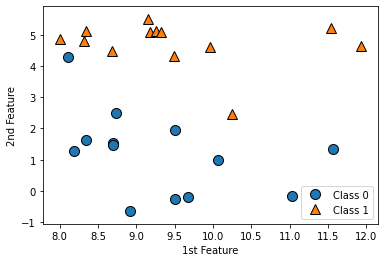

In [12]:
# 데이터셋을 만듭니다
X, y = mglearn.datasets.make_forge()
# 산점도를 그립니다.
mglearn.discrete_scatter(X[:,0], X[:,1], y)
plt.legend(['Class 0', 'Class 1'], loc=4)
plt.xlabel('1st Feature')
plt.ylabel('2nd Feature')

X.shape

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function make_blobs is deprecated; Please import make_blobs directly from scikit-learn
  warnings.warn(msg, category=FutureWarning)


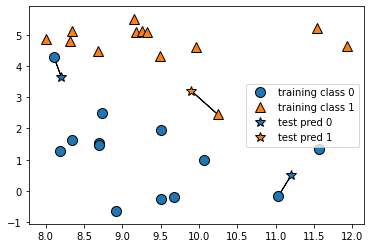

In [13]:
# 예시: forge 데이터셋에 대한 1-최근접 이웃 모델의 예측
mglearn.plots.plot_knn_classification(n_neighbors=1)

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function make_blobs is deprecated; Please import make_blobs directly from scikit-learn
  warnings.warn(msg, category=FutureWarning)


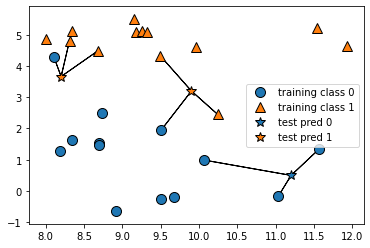

In [14]:
# 예시: forge 데이터셋에 대한 3-최근접 이웃 모델의 예측
mglearn.plots.plot_knn_classification(n_neighbors=3)

#### <U>*k-최근접 이웃 알고리즘 적용*</U>

In [15]:
# 훈련셋-데이터셋 분리
from sklearn.model_selection import train_test_split
X, y = mglearn.datasets.make_forge()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function make_blobs is deprecated; Please import make_blobs directly from scikit-learn
  warnings.warn(msg, category=FutureWarning)


In [16]:
# 모델 임포트 및 객체화
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=3) # 객체 저장 시 이웃 수를 지정

In [17]:
# 학습 진행
clf.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [18]:
# 테스트셋에 대한 예측 진행
print('테스트 세트 예측:', clf.predict(X_test))

테스트 세트 예측: [1 0 1 0 1 0 0]


In [19]:
# 평가 (일반화 정도)
print('테스트 세트 정확도: {:.2f}'.format(clf.score(X_test, y_test)))

테스트 세트 정확도: 0.86


#### <U>*KNeighborsClassifier 분석*</U>

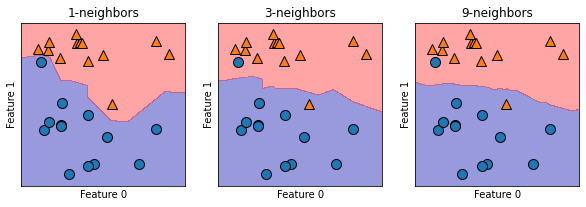

In [20]:
# 결정 경계(decision boundary) 확인
fig, axes = plt.subplots(1, 3, figsize=(10,3))

for n_neighbors, ax in zip([1, 3, 9], axes):
    # fit 메소드는 self 오브젝트를 리턴 -> 객체 생성과 fit 메소드를 한 줄에 작성 가능
    clf = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X, y)
    
    mglearn.plots.plot_2d_separator(clf, X, fill=True, eps=0.5, ax=ax, alpha=0.4) # 결정 경계
    mglearn.discrete_scatter(X[:,0], X[:,1], y, ax=ax) # Scatter
    
    ax.set_title('{}-neighbors'.format(n_neighbors))
    ax.set_xlabel('Feature 0')
    ax.set_ylabel('Feature 1')

- **이웃의 늘릴수록 결정 경계는 더 부드러워짐, 부드러운 경계는 더 단순한 모델을 의미**
- 이웃을 적게 사용하면 모델의 복잡도가 높아지고, 많이 사용하면 복잡도는 낮아짐

#### <U>*모델의 복잡도와 일반화 사이 관계*</U>
    - scikit-learn의 유방암 데이터셋 사용

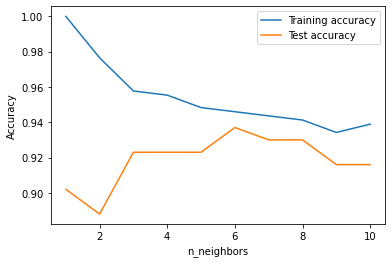

In [21]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=66)

training_accuracy = []
test_accuracy = []

# 1에서 10까지 n_neighbors를 적용
neighbors_setting = range(1,11)

for n_neighbors in neighbors_setting:
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train, y_train)
    # 훈련 세트 정확도 저장
    training_accuracy.append(clf.score(X_train, y_train))
    # 테스트 세트 정확도 저장
    test_accuracy.append(clf.score(X_test, y_test))
    
plt.plot(neighbors_setting, training_accuracy, label='Training accuracy')
plt.plot(neighbors_setting, test_accuracy, label='Test accuracy')
plt.ylabel('Accuracy')
plt.xlabel('n_neighbors')
plt.legend()

- 이웃의 수가 하나일 때는 훈련 데이터에 대한 예측이 완벽하나, 테스트 세트의 정확도는 낮아짐 -> 과대 적합(overfitting) 위험
- 이웃의 수가 10개 사용했을때는 모델이 너무 단순해서 정확도가 나빠짐 -> 과소 적합(underfitting) 위험
- 최적점이 존재함 (위 문제에서는 이웃 6개 사용)

#### <U>*k-최근접 이웃 회귀*</U>
    -mglearn의 wave 데이터셋 사용

Text(0, 0.5, 'Target')

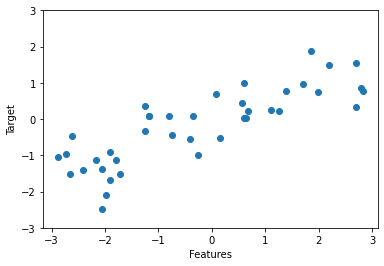

In [22]:
X, y = mglearn.datasets.make_wave(n_samples=40)
plt.plot(X, y, 'o')
plt.ylim(-3,3)
plt.xlabel('Features')
plt.ylabel('Target')

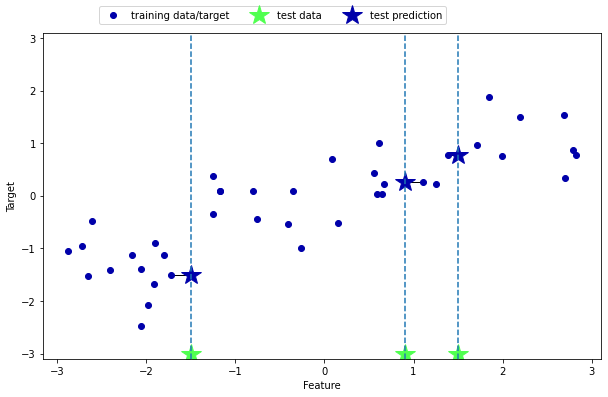

In [23]:
# wave 데이터셋에 대한 1-최근접 이웃 회귀 모델의 예측
# = 가장 가까운 이웃의 타깃 값 취함
mglearn.plots.plot_knn_regression(n_neighbors=1)

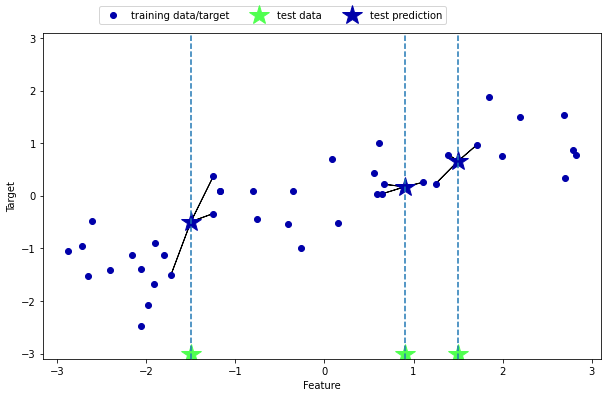

In [24]:
# wave 데이터셋에 대한 3-최근접 이웃 회귀 모델의 예측
# = 여러개의 최근접 이웃을 사용할 땐 이웃 간의 평균을 취함
# -> KNeighborsRegressor의 weights 매개변수가 기본값 'uniform'일때는 np.mean 함수를 사용하여 단순 평균을 계산하고, 
# 'distance'일 때는 거리를 고려한 가중치 평균(average)을 계산
mglearn.plots.plot_knn_regression(n_neighbors=3)

#### <U>*k-최근접 이웃 알고리즘 적용(회귀)*</U>

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
X, y = mglearn.datasets.make_wave(n_samples=40)

# wave 데이터셋을 훈련 세트와 테스트 세트로 나눔
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
# 이웃의 수를 3으로 하여 모델의 객체 생성
reg = KNeighborsRegressor(n_neighbors=3)
# 훈련 데이터와 타깃을 사용하여 모델을 학습
reg.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=3)

In [26]:
reg.predict(X_test)

array([-0.05396539,  0.35686046,  1.13671923, -1.89415682, -1.13881398,
       -1.63113382,  0.35686046,  0.91241374, -0.44680446, -1.13881398])

In [27]:
reg.score(X_test, y_test)

0.8344172446249605

- 역시 score 메서드를 사용해 모델 평가 가능
- 회귀일 땐 R2 값을 반환 : 0과 1사이 값으로 1일 경우 완벽한 예측, **0은 훈련 세트의 출력값인 y_train의 평균으로만 예측하는 모델임**
- R2은 음수가 될 수도 있음, 이때는 예측과 타깃이 서로 상반된 경향을 가지는 경우임

#### <U>*KNeighborsRegressor 분석*</U>

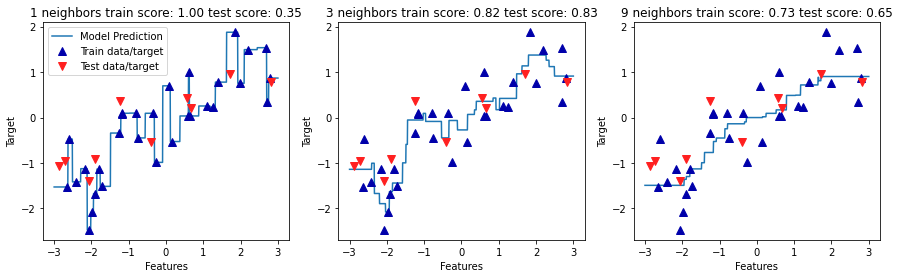

In [28]:
fig, axes = plt.subplots(1,3, figsize=(15,4))
# -3과 3 사이에 1,000 개의 데이터 포인트를 생성
line = np.linspace(-3, 3, 1000).reshape(-1,1) # reshape을 통해 2차원 배열화, 머신러닝 적용 가능

for n_neighbors, ax in zip([1, 3, 9], axes):
    # 1, 3, 9 이웃을 사용한 예측 진행
    reg = KNeighborsRegressor(n_neighbors=n_neighbors)
    reg.fit(X_train, y_train)
    ax.plot(line, reg.predict(line))
    ax.plot(X_train, y_train, '^', c=mglearn.cm2(0), markersize=8)
    ax.plot(X_test, y_test, 'v', c=mglearn.cm2(1), markersize=8)
    
    ax.set_title(
        '{} neighbors train score: {:.2f} test score: {:.2f}'.format(
        n_neighbors, reg.score(X_train, y_train), reg.score(X_test, y_test)))
    
    ax.set_xlabel('Features')
    ax.set_ylabel('Target')

axes[0].legend(['Model Prediction', 'Train data/target', 'Test data/target'], loc='best')

- 이웃을 하나만 사용할 때는 훈련 세트의 각 데이터 포인트가 예측에 주는 영향이 커서 **예측값이 훈련 데이터 포인트를 모두 지남(overfitting)**
- 이웃을 많이 사용하면 **훈련 데이터에는 잘 안 맞을 수 있지만(underfitting), 더 안정된 예측을 보임**

### 2.3.4 나이브 베이즈 분류기
- ***각 특성을 개별로 취급해 파라미터를 학습하고 각 특성에서 클래스별 통계를 단순하게 취합***
- 분류기의 종류
> - **GaussianNB(연속데이터), BernoulliNB(이진데이터), MultinomialNB(카운트데이터)**
> - GaussianNB는 대부분 매우 고차원적인 데이터셋에 사용하고, BernoulliNB, MultinomialNB는 대부분 텍스트 데이터를 분류할 때 사용
> - MultinomalNB는 보통 0이 아닌 특성이 비교적 많은 데이터 셋(큰문서)에서 BernoulliNB보다 성능이 높음
> - GaussianNB는 클래스별로 각 특성의 분산과 평균을 저장, BernoulliNB는 클래스의 특성 중 0이 아닌 것의 갯수 카운트(sum), MultinomalNB는 클래스별로 특성의 평균을 계산
- 예측할 땐 데이터 포인트를 클래스의 통계 값과 비교해서 가장 잘 맞는 클래스를 예측 값으로 도출

- **장단점**
> - LogisticRegression이나 LinearSVC 같은 선형 분류보보다 **훈련 속도가 빠른 편이지만, 그 대신 일반화 성능이 조금 떨어짐**
> - 훈련 과정을 이해하기 쉽고, 비교적 매개변수에 민감하지 않음
> - **선형 모델로는 학습 시간이 너무 오래 걸리는 매우 큰 데이터 셋에 적용해 봄직함**

- **매개변수**
> - BernoulliNB와 MultinomialNB는 모델의 복잡도를 조절하는 alpha 매개변수 하나를 가짐
> - **alpha가 주어지면 알고리즘이 모든 특성에 양의 값을 가진 가상의 데이터 포인트를 alpha 개수만큼 추가 -> 통계 데이터를 완만하게 만들어주므로 alpha가 크면 모델의 복잡도가 낮아짐(일반화)**
> - alpha 값이 성능 향상에 크게 기여하지 않으나, 조정 시 정확도를 일부 높일 수 있음

In [31]:
# BernoulliNB 계산 방식 예시
X = np.array([[0,1,0,1],
              [1,0,1,1],
              [0,0,0,1],
              [1,0,1,0]])
y = np.array([0,1,0,1])

In [35]:
counts = {}
for label in np.unique(y):
    print(label)
    counts[label] = X[y==label]
    print(counts)

0
{0: array([[0, 1, 0, 1],
       [0, 0, 0, 1]])}
1
{0: array([[0, 1, 0, 1],
       [0, 0, 0, 1]]), 1: array([[1, 0, 1, 1],
       [1, 0, 1, 0]])}


In [32]:
counts = {}
for label in np.unique(y):
    print(label)
    counts[label] = X[y==label].sum(axis=0)
    print(counts)

0
{0: array([0, 1, 0, 2])}
1
{0: array([0, 1, 0, 2]), 1: array([2, 0, 2, 1])}


## 2.4 분류 예측의 불확실성 추정
- 어떤 테스트 포인트에 대해 분류기가 예측한 클래스가 무엇인지 뿐만 아니라 정확한 클래스임을 얼마나 확신하는지도 중요함
- scikit-learn **분류기에서 불확실성을 추정**할 수 있는 함수가 두 개 -> **dicision_function(결정함수), predict_proba(예측 확률)//**

In [2]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import make_circles
X, y = make_circles(noise=0.25, factor=0.5, random_state=1)

# 예제를 위한 클래스의 이름을 'blue'와 'red'로 변경
y_named = np.array(['blue', 'red'])[y]

# 여러 개의 배열을 한꺼번에 train_test_split에 넣을 수 있음
# 훈련 세트와 테스트 세트로 나뉘는 방식은 모두 동일
X_train, X_test, y_train_named, y_test_named, y_train, y_test = train_test_split(X, y_named, y, random_state=0)

# 그레디언트 부스팅 모델 생성
gbrt = GradientBoostingClassifier(random_state=0)
gbrt.fit(X_train, y_train_named)

GradientBoostingClassifier(random_state=0)

### 2.4.1 결정 함수
- 이진 분류에서 ***decision_function*** 반환 값의 크기는 (n_samples,)이며 각 샘플이 하나의 실수 값을 반환
- 해당 값은 **데이터 포인트가 양성 클래스인 클래스 1에 속한다고 믿는 정도**를 가리킴, **양수 값은 양성 클래스 의미**하고 **음수 값은 음성(즉 다른) 클래스를 의미**

In [5]:
print('X_test.shape', X_test.shape)
print('결정함수 결과 형태', gbrt.decision_function(X_test).shape)

X_test.shape (25, 2)
결정함수 결과 형태 (25,)


In [6]:
print('결정 함수\n', gbrt.decision_function(X_test)[:6])

결정 함수
 [ 4.13592603 -1.70169917 -3.95106099 -3.62609552  4.28986642  3.66166081]


> - decistion_function 값의 범위는 데이터와 모델 파라미터에 따라 달라짐
> - 출력 범위가 임의의 값이라 이해하기 어려움

In [7]:
decision_function = gbrt.decision_function(X_test)
print('결정 함수 최솟값: {:.2f} 최댓값: {:.2f}'.format(np.min(decision_function), np.max(decision_function)))

결정 함수 최솟값: -7.69 최댓값: 4.29


> - 2차원 평면의 모든 점에 대해 decision_function의 값을 색으로 표현(우)하여 앞서 본 결정 경계(좌)와 비교

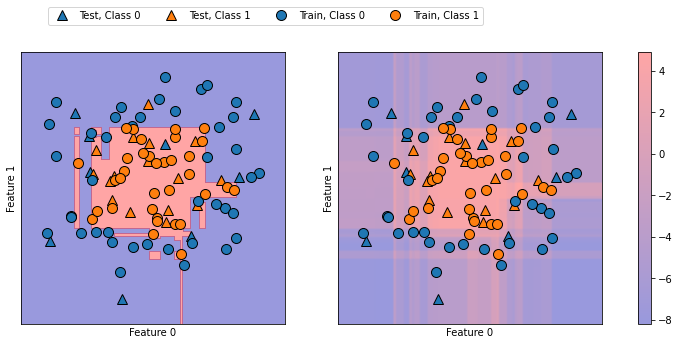

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
mglearn.tools.plot_2d_separator(gbrt, X, ax=axes[0], alpha=0.4, fill=True, cm=mglearn.cm2)
scores_image = mglearn.tools.plot_2d_scores(gbrt, X, ax=axes[1], alpha=0.4, cm=mglearn.ReBl)

for ax in axes:
    # 훈련 포인트와 테스트 포인트를 그리기
    mglearn.discrete_scatter(X_test[:,0], X_test[:,1], y_test, markers='^', ax=ax)
    mglearn.discrete_scatter(X_train[:,0], X_train[:,1], y_train, markers='o', ax=ax)
    ax.set_xlabel('Feature 0')
    ax.set_ylabel('Feature 1')

cbar = plt.colorbar(scores_image, ax=axes.tolist())
cbar.set_alpha(1)
fig.draw_without_rendering() #cbar.draw_all()
axes[1].legend(['Test, Class 0', 'Test, Class 1', 'Train, Class 0', 'Train, Class 1'], ncol=4, loc=(-1.1,1.1))

### 2.4.2 예측 확률
- ***predict_proba*의 출력은 각 클래스에 대한 확률**이고 decision_function의 출력보다 이해하기 쉬움
- 이진 분류에서의 출력 값 형태는 (n_samples, 2)이고, 첫 번째 원소는 첫 번째 클래스의 두 번째 원소는 두 번째 클래스의 예측 확률임
- 데이터에 있는 불확실성이 얼마나 예측 확률에 잘 반영되었는지는 모델과 매개변수 설정에 달렸음
> - **과대 적합된 모델은 혹 잘못된 예측이더라도 예측의 확신이 강한 편**
> - 일반적으로 복잡도가 낮은 모델은 예측에 불확실성이 더 높음
- 불확실성과 모델의 정확도가 동등하면 이 모델이 보정(calibration) 되었다고 말함

In [9]:
print('확률 값의 형태:', gbrt.predict_proba(X_test).shape)

확률 값의 형태: (25, 2)


In [10]:
print('예측 확률:\n', gbrt.predict_proba(X_test[:6]))

예측 확률:
 [[0.01573626 0.98426374]
 [0.84575653 0.15424347]
 [0.98112869 0.01887131]
 [0.97407033 0.02592967]
 [0.01352142 0.98647858]
 [0.02504637 0.97495363]]


> - 결정 경계와 클래스 1의 확률 도식화

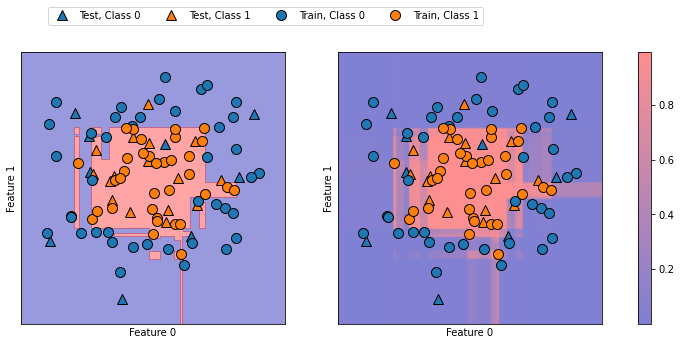

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

mglearn.tools.plot_2d_separator(gbrt, X, ax=axes[0], alpha=0.4, fill=True, cm=mglearn.cm2)
scores_image = mglearn.tools.plot_2d_scores(gbrt, X, ax=axes[1], alpha=0.5, cm=mglearn.ReBl, 
                                            function='predict_proba')

for ax in axes:
    # 훈련 포인트와 테스트 포인트를 그리기
    mglearn.discrete_scatter(X_test[:,0], X_test[:,1], y_test, markers='^', ax=ax)
    mglearn.discrete_scatter(X_train[:,0], X_train[:,1], y_train, markers='o', ax=ax)
    ax.set_xlabel('Feature 0')
    ax.set_ylabel('Feature 1')

cbar = plt.colorbar(scores_image, ax=axes.tolist())
cbar.set_alpha(1)
fig.draw_without_rendering() #cbar.draw_all()
axes[1].legend(['Test, Class 0', 'Test, Class 1', 'Train, Class 0', 'Train, Class 1'], ncol=4, loc=(-1.1,1.1))

- 결정 함수 대비 예측 확률의 그래프의 경계가 훨씬 명확하게 나타났으며, 불확실성이 있는 작은 영역들도 잘 확인할 수 있음

### 2.4.3 다중 분류에서의 불확실성
- 다중 분류에서는 *decision_function*의 결과값 크기는 (n_samples, n_classes), 각 열은 각 클래스에 대한 확신 점수를 나타냄
- *predict_proba*의 출력값 크기는 (n_samples, n_classes)

In [12]:
# 클래스가 3개인 iris 데이터셋

from sklearn.datasets import load_iris

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, random_state=42)

gbrt = GradientBoostingClassifier(learning_rate=0.01, random_state=0)
gbrt.fit(X_train, y_train)

print('결정 함수의 결과 형태:', gbrt.decision_function(X_test).shape)
print('결정 함수의 결과:\n', gbrt.decision_function(X_test)[:6, :])

결정 함수의 결과 형태: (38, 3)
결정 함수의 결과:
 [[-1.995715    0.04758267 -1.92720695]
 [ 0.06146394 -1.90755736 -1.92793758]
 [-1.99058203 -1.87637861  0.09686725]
 [-1.995715    0.04758267 -1.92720695]
 [-1.99730159 -0.13469108 -1.20341483]
 [ 0.06146394 -1.90755736 -1.92793758]]


In [13]:
print('가장 큰 결정 함수의 인덱스:\n',
      np.argmax(gbrt.decision_function(X_test), axis=1))
print('예측:\n', gbrt.predict(X_test))

가장 큰 결정 함수의 인덱스:
 [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0]
예측:
 [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0]


In [14]:
# predict_proba 결과 중 앞 부분 확인
print('예측 확률:\n', gbrt.predict_proba(X_test)[:6])

# 행 방향으로 확률을 더하면 1이 됨
print('합:', gbrt.predict_proba(X_test)[:6].sum(axis=1))

예측 확률:
 [[0.10217718 0.78840034 0.10942248]
 [0.78347147 0.10936745 0.10716108]
 [0.09818072 0.11005864 0.79176065]
 [0.10217718 0.78840034 0.10942248]
 [0.10360005 0.66723901 0.22916094]
 [0.78347147 0.10936745 0.10716108]]
합: [1. 1. 1. 1. 1. 1.]


In [ ]:
> - predict의 결과와 decision_function이나 predict_proba의 결과를 비교하려면 **분류기의 classes_속성을 사용해 클래스의 실제 이름**을 얻어야 함

In [20]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000)

# iris 데이터셋의 타깃을 클래스 이름으로 나타내기
named_target = iris.target_names[y_train]
logreg.fit(X_train, named_target)

print('훈련 데이터에 있는 클래스 종류:', logreg.classes_)
print('예측:', logreg.predict(X_test)[:10])

argmax_dec_func = np.argmax(logreg.decision_function(X_test), axis=1)

print('가장 큰 결정 함수의 인덱스:', argmax_dec_func[:10])

훈련 데이터에 있는 클래스 종류: ['setosa' 'versicolor' 'virginica']
예측: ['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor']
가장 큰 결정 함수의 인덱스: [1 0 2 1 1 0 1 2 1 1]
